# 04 — Model 2: Shallow 1D CNN

This is **Model 2** of the thesis's complexity ladder:

> **linear → shallow CNN → medium CNN → deep CNN → transformer**

Model 1 was a linear baseline on hand-crafted band-power features (~6 parameters). Model 2 is the
**first neural network**, and the first model that reads the **raw 96-timestep signal** directly and
learns its own features. It anchors the **low end** of the parameter ladder.

**Complexity = parameter count.** In this thesis, model complexity is operationalised as the number
of trainable parameters — it is the **x-axis** of the central result (CMI vs. complexity), so it is
the independent variable, not an incidental detail. Every model reports its exact parameter count.

> Scope: this notebook is **build-and-train only** — no XAI / harness here. We first need a trained
> model that clears the accuracy bar; the faithfulness analysis comes later.

## 1. What is a 1D CNN, and why does it suit raw time-series?

A **convolutional neural network (CNN)** learns small **pattern detectors** (called *filters* or
*kernels*) and slides each one along the signal, computing how strongly that local pattern matches
at every position. For a 1D time-series this is very natural: a filter of width 7 looks at 7
consecutive timesteps at a time and can learn to fire on, say, a sharp downward deflection (like a
QRS complex) — and because the *same* filter slides across the whole signal, it detects that pattern
**wherever** it occurs (this is *translation equivariance*, and it's why CNNs are data-efficient).

The standard building block, repeated a few times, is:

- **Conv1d** — the sliding pattern detectors (many filters, each producing one "response" channel).
- **BatchNorm** — rescales activations so training is stable and faster.
- **ReLU** — a non-linearity (keeps positive responses, zeros negatives) so the network can learn
  non-linear combinations.
- **MaxPool** — halves the length by keeping the strongest response in each small window, making the
  representation coarser and more robust to small shifts.

Stacking these blocks builds a hierarchy: early filters catch fine local shapes, later ones (seeing
pooled inputs) catch broader patterns. Finally, **Global Average Pooling** averages each channel over
time down to a single number, and a small **linear head** maps those to the class scores. We choose a
**kernel size of 7** because notebook 01b found ECG200's natural correlation length is ~5–10 timesteps
— so each filter sees roughly one coherent unit of signal.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.data.preprocessing import load_ecg200
from src.models.cnn import (
    build_cnn, count_parameters, train_cnn, torch_predict_proba, set_seed,
    SEED, LEARNING_RATE, BATCH_SIZE, MAX_EPOCHS, PATIENCE, WEIGHT_DECAY, KERNEL_SIZE,
    CNN_VARIANTS,
)
from src.evaluation.metrics import classification_metrics, format_metrics, overfitting_gap

FIG_DIR = PROJECT_ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

# Same cached ECG200 split every model sees (identical data to Model 1).
X_train, y_train = load_ecg200("train")
X_val,   y_val   = load_ecg200("val")
X_test,  y_test  = load_ecg200("test")
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"class-1 share: train {100*y_train.mean():.0f}%  test {100*y_test.mean():.0f}%")
# The CNN expects (n, channels, time); this reshape (n,96)->(n,1,96) happens
# inside train_cnn / predict_proba, so we pass the raw (n, 96) arrays as-is.

train (80, 96)  val (20, 96)  test (100, 96)
class-1 share: train 69%  test 64%


## 2. The architecture — a shallow CNN

Model 2 is deliberately **shallow** — the low end of the ladder. We use **2 convolution blocks** with
channel widths **[16, 32]** and kernel size 7, then Global Average Pooling and a linear head to 2
classes. One `CNN1D` module produces all of Models 2–4 by changing the list of channel widths
(`conv_channels`) — depth is its length, width is its values — so Models 3 (medium) and 4 (deep) reuse
this exact code, just with wider/deeper configs. That keeps the ladder consistent: the models differ
in **complexity**, not in unrelated design choices.

In [2]:
set_seed(SEED)   # anchor weight init BEFORE building, so the result is
                 # reproducible regardless of any other models built earlier
model = build_cnn(variant="shallow", n_classes=2, in_channels=1, kernel_size=KERNEL_SIZE)
n_params = count_parameters(model)
print(model)
print(f"\nModel 2 (shallow) trainable parameters: {n_params:,}")
print("\nCNN ladder configs (Models 2-4):")
for v in CNN_VARIANTS:
    print(f"  {v:8s} channels={CNN_VARIANTS[v]}  params={count_parameters(build_cnn(v)):,}")

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (head): Linear(in_features=32, out_features=2, bias=True)
)

Model 2 (shallow) trainable parameters: 3,858

CNN ladder configs (Models 2-4):
  shallow  channels=[16, 32]  params=3,858
  medium   channels=[32, 64, 64]  params=43,682
  deep     channels=[64, 128, 128, 256]  params=403,522


## 3. The training recipe (shared by Models 3–5)

We fix **one** training recipe here and reuse it verbatim for Models 3–5, so the models differ in
complexity rather than in confounded training differences:

- **Optimiser:** Adam, learning rate 1e-3, small weight decay (1e-4) for mild regularisation on the
  tiny 80-sample training set.
- **Batch size 16**, up to **200 epochs**, with **early stopping** (patience 30) and
  **best-validation-loss checkpointing** — we keep the weights from the epoch with the lowest
  validation loss, so we neither under- nor over-train.
- **Class imbalance:** ECG200 is ~65/35, so we use **class-weighted cross-entropy** (inverse
  frequency) — the minority (abnormal) class is up-weighted so the model can't win by always
  predicting "normal". We report **balanced accuracy and F1**, not just raw accuracy.
- **Fixed seed (42)** for reproducibility, and the **same cached split** as Model 1.

In [3]:
result = train_cnn(model, X_train, y_train, X_val, y_val)   # recipe defaults; seed=42
print(f"training finished: best epoch = {result['best_epoch']} "
      f"(of {len(result['history']['train_loss'])} run), recipe: "
      f"Adam lr={LEARNING_RATE}, batch={BATCH_SIZE}, wd={WEIGHT_DECAY}, "
      f"patience={PATIENCE}, seed={SEED}")

training finished: best epoch = 174 (of 200 run), recipe: Adam lr=0.001, batch=16, wd=0.0001, patience=30, seed=42


### Training curves

The left panel shows the **loss** falling on both train and validation as the model learns; the right
shows **validation balanced accuracy** climbing. What to look for: loss decreasing without the
validation curve turning sharply back up (which would signal severe overtraining), and the
best-checkpoint epoch (dashed line) near where validation was best.

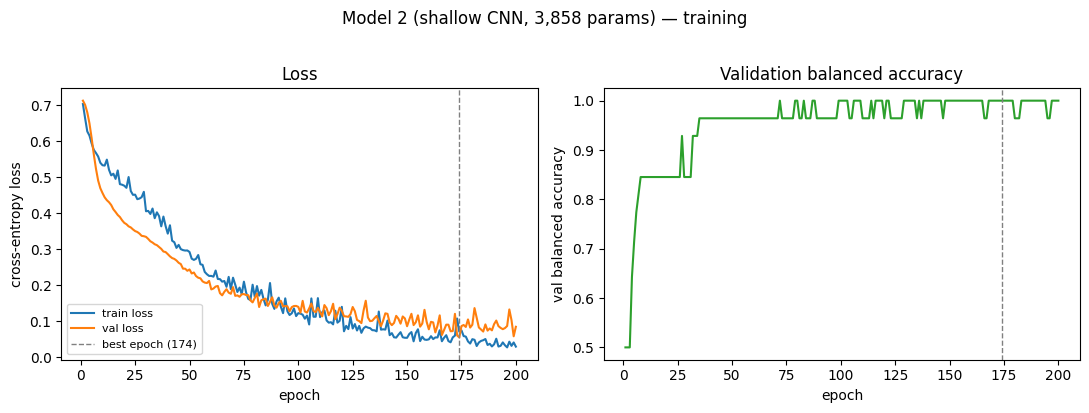

In [4]:
h = result["history"]; epochs = np.arange(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, h["train_loss"], label="train loss")
ax[0].plot(epochs, h["val_loss"], label="val loss")
ax[0].axvline(result["best_epoch"], color="grey", ls="--", lw=1, label=f"best epoch ({result['best_epoch']})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy loss"); ax[0].set_title("Loss"); ax[0].legend(fontsize=8)
ax[1].plot(epochs, h["val_balanced_accuracy"], color="C2")
ax[1].axvline(result["best_epoch"], color="grey", ls="--", lw=1)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val balanced accuracy"); ax[1].set_title("Validation balanced accuracy")
fig.suptitle(f"Model 2 (shallow CNN, {n_params:,} params) — training", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_model2_training.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Results and the accuracy gate

We evaluate on train, validation, and the held-out **test** set (the honest number). The experiment
plan requires **> 80% test accuracy** — a model that barely learns isn't a meaningful subject for
faithfulness analysis. We also record the **overfitting gap** (train/val accuracy − test accuracy),
which we track for *every* model up the ladder, alongside CMI, because it is expected to grow with
parameter count and is a confound to watch.

In [5]:
predict_proba = torch_predict_proba(model)   # the harness interface (see next cell)

splits = {}
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    prob = predict_proba(X); pred = prob.argmax(1)
    splits[name] = classification_metrics(y, pred, prob)
    print(f"{name:5s} {format_metrics(splits[name])}")

test_acc = splits["test"]["accuracy"]
gap_train = overfitting_gap(splits["train"]["accuracy"], test_acc)
gap_val   = overfitting_gap(splits["val"]["accuracy"], test_acc)
print(f"\noverfitting gap:  train-test = {gap_train:+.3f}   val-test = {gap_val:+.3f}")
print(f"\n>>> 80% ACCURACY GATE: {'PASS' if test_acc >= 0.80 else 'FAIL'}  (test accuracy {test_acc:.3f})")

train accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000
val   accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000
test  accuracy=0.810  balanced_accuracy=0.785  f1=0.855  roc_auc=0.848

overfitting gap:  train-test = +0.190   val-test = +0.190

>>> 80% ACCURACY GATE: PASS  (test accuracy 0.810)


### What the results mean

Model 2 (shallow CNN, **3,858 parameters**) reaches **test accuracy ≈ 0.81** (balanced accuracy ≈ 0.79,
F1 ≈ 0.86, ROC-AUC ≈ 0.85) — it **clears the 80% gate**, so it is a valid subject for the later
faithfulness analysis. Note the **overfitting gap**: validation is a perfect 1.00 but test is 0.81
(val−test ≈ 0.19). That gap is expected on ECG200's tiny 80-sample training set, and it will tend to
**grow as we add parameters** up the ladder — so we record it now for every model. It is a confound
for the central question (a CMI change could partly reflect overfitting rather than complexity), and
we will report it alongside CMI as an interpretive caveat.

## 5. The harness interface (compatibility check — no XAI yet)

`torch_predict_proba(model)` exposes the **same `predict_proba` contract Model 1 exposes**, and the
same one FeatureAblation / KernelSHAP / the deletion curves call: it maps a batch of raw signals
`(n, T)` (or `(n, C, T)`) to class probabilities `(n, n_classes)`. We only check the *contract* here
(shape and that rows are probabilities) — we do **not** run any XAI in this notebook. Because the
contract matches, Model 2 plugs into the existing harness unchanged at the (later) faithfulness step.

In [6]:
demo = predict_proba(X_test[:3])
print("predict_proba(X_test[:3]) shape:", demo.shape, "(expect (3, 2))")
print("rows are probabilities (sum to 1):", np.allclose(demo.sum(1), 1.0))
print("example row:", np.round(demo[0], 3))

predict_proba(X_test[:3]) shape: (3, 2) (expect (3, 2))
rows are probabilities (sum to 1): True
example row: [0.006 0.994]


## Summary

**Model 2 — shallow 1D CNN, 3,858 parameters, test accuracy ≈ 0.81 (PASS).** The first neural rung of
the complexity ladder is trained and validated. The `CNN1D` module and the shared training recipe are
now in place, so **Model 3 (medium, ~44k params)** and **Model 4 (deep, ~404k)** reuse this code with
wider/deeper configs, and Model 5 (transformer) reuses the recipe. Overfitting is now a tracked
quantity. See `DECISIONS_LOG.md` for the ladder, the recipe, and the complexity framing.

## 6. Attribution methods on Model 2 (inspection only — no scoring yet)

Now that Model 2 is trained, we ask each attribution method **where the model relies** on the
signal. This is an **inspection step**: we look at the raw per-region attributions and sanity-check
them. We do **not** compute the faithfulness harness (deletion curves / DDS / PES / CMI /
concentration) here — that is the next step. First we want to *see* what each method says and confirm
it's sane before we score it.

Three methods, all producing **one value per region** on the existing region grid:

- **KernelSHAP** and **FeatureAblation** — reused unchanged from the harness (grid-native via
  `feature_mask = grid.labels`); Model 2 exposes the same `predict_proba` contract, so they plug in
  as-is. KernelSHAP samples coalitions, so it's seeded (**seed = 0**, recorded); FeatureAblation is
  deterministic.
- **Integrated Gradients (IG)** — **new** here. It is gradient-based, so it couldn't run on the
  linear Model 1 but can now use the CNN's gradients.

### Integrated Gradients — three deliberate choices

- **Baseline = the Zero PM background.** IG measures importance *relative to a reference input*; we
  use the same **zero** baseline as our Zero perturbation method, so IG is comparable to the other
  methods. (On ECG200 the signals are per-sample z-scored, mean ≈ 0, so the zero baseline also ≈ the
  sample-mean baseline — the two nearly coincide here.)
- **Pool to regions by SUMMING.** IG gives per-timestep attributions; we sum them within each region.
  IG satisfies **completeness** — the per-timestep values sum to `prob(input) − prob(baseline)` — so
  summing within a region keeps that additive meaning (each region's value = its share of the output
  change). The region is the reported unit; per-timestep values are only an intermediate.
- **BatchNorm / gradient hygiene.** The model is put in **eval mode** so BatchNorm uses fixed running
  statistics (otherwise IG's interpolated batch would corrupt the gradients), and gradients flow
  normally. We check the output isn't all-zero/degenerate below.

In [7]:
from src.xai.regions import build_region_grid, REGION_SIZE_PRIMARY_PCT
from src.xai.feature_ablation import feature_ablation
from src.xai.kernel_shap import kernel_shap
from src.xai.integrated_gradients import integrated_gradients

grid = build_region_grid(X_test.shape[1], REGION_SIZE_PRIMARY_PCT)   # 10% grid, 10 regions
n_reg = grid.n_regions
# `model` and `predict_proba` come from the training cells above (Model 2, trained).

# Per-region attributions for the whole test set (KS seed=0; FA & IG deterministic).
FA = np.array([feature_ablation(predict_proba, s, grid, "zero") for s in X_test])
KS = np.array([kernel_shap(predict_proba, s, grid, "zero") for s in X_test])
IG = np.array([integrated_gradients(model, s, grid, "zero") for s in X_test])

# --- IG sanity: completeness + not degenerate ---
tc0 = int(predict_proba(X_test[:1])[0].argmax())
compl_err = np.mean([
    abs(integrated_gradients(model, s, grid, "zero").sum()
        - (predict_proba(s[None, :])[0].max() - predict_proba(np.zeros_like(s)[None, :])[0, int(predict_proba(s[None,:])[0].argmax())]))
    for s in X_test[:20]
])
print(f"IG sanity: not all-zero = {not np.allclose(IG, 0)}, "
      f"nonzero regions = {(np.abs(IG).sum(0) > 1e-9).sum()}/{n_reg}, "
      f"mean|completeness error| (20 samples) = {compl_err:.4f}")

# Normalised mean importance profile per method (mean |attr| over test set, scaled to max 1).
def profile(A):
    m = np.abs(A).mean(axis=0)
    return m / m.max()
prof = {"FeatureAblation": profile(FA), "KernelSHAP": profile(KS), "IntegratedGradients": profile(IG)}
for name, v in prof.items():
    print(f"{name:20s} per-region importance:", np.round(v, 2))
print("\nprofile agreement (correlation):",
      f"FA-KS={np.corrcoef(prof['FeatureAblation'],prof['KernelSHAP'])[0,1]:.2f}",
      f"FA-IG={np.corrcoef(prof['FeatureAblation'],prof['IntegratedGradients'])[0,1]:.2f}",
      f"KS-IG={np.corrcoef(prof['KernelSHAP'],prof['IntegratedGradients'])[0,1]:.2f}")

IG sanity: not all-zero = True, nonzero regions = 10/10, mean|completeness error| (20 samples) = 0.0017
FeatureAblation      per-region importance: [1.   0.25 0.22 0.29 0.17 0.13 0.18 0.17 0.1  0.23]
KernelSHAP           per-region importance: [1.   0.21 0.26 0.17 0.13 0.16 0.22 0.19 0.11 0.16]
IntegratedGradients  per-region importance: [1.   0.47 0.65 0.43 0.33 0.29 0.26 0.28 0.27 0.18]

profile agreement (correlation): FA-KS=0.98 FA-IG=0.87 KS-IG=0.88


### Where does each method point?

We plot the per-region importance (normalised |attribution|, so the three methods are on a common
0–1 scale and we compare *where* they point, not their raw magnitudes). Top: averaged across the
whole test set. Below: two individual example beats (one predicted-normal, one predicted-abnormal).
The grey curve is the signal; the coloured step-lines are each method's per-region importance, held
constant within a region.

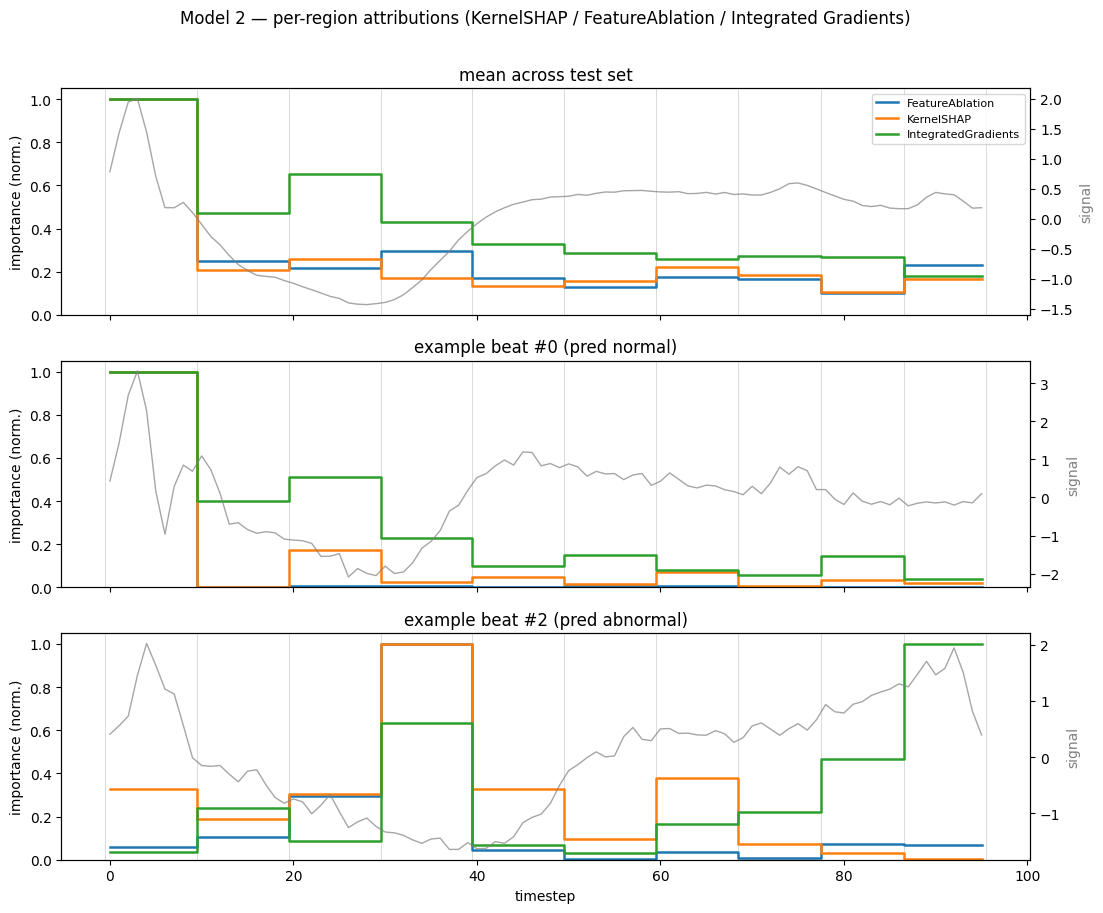

In [8]:
t = np.arange(X_test.shape[1])
to_steps = lambda p: p[grid.labels]     # (n_regions,) -> per-timestep step function

# choose two example beats with different predicted classes
preds = predict_proba(X_test).argmax(1)
idx_norm = int(np.where(preds == 1)[0][0])
idx_abn  = int(np.where(preds == 0)[0][0])

rows = [
    ("mean across test set", X_test.mean(0), {k: profile(v) for k, v in [("FeatureAblation",FA),("KernelSHAP",KS),("IntegratedGradients",IG)]}),
    (f"example beat #{idx_norm} (pred normal)", X_test[idx_norm],
        {"FeatureAblation": np.abs(FA[idx_norm])/np.abs(FA[idx_norm]).max(),
         "KernelSHAP":      np.abs(KS[idx_norm])/np.abs(KS[idx_norm]).max(),
         "IntegratedGradients": np.abs(IG[idx_norm])/np.abs(IG[idx_norm]).max()}),
    (f"example beat #{idx_abn} (pred abnormal)", X_test[idx_abn],
        {"FeatureAblation": np.abs(FA[idx_abn])/np.abs(FA[idx_abn]).max(),
         "KernelSHAP":      np.abs(KS[idx_abn])/np.abs(KS[idx_abn]).max(),
         "IntegratedGradients": np.abs(IG[idx_abn])/np.abs(IG[idx_abn]).max()}),
]
colors = {"FeatureAblation": "C0", "KernelSHAP": "C1", "IntegratedGradients": "C2"}

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, (title, sig, profs) in zip(axes, rows):
    for b in np.append(grid.bounds[:, 0], grid.bounds[-1, 1]):
        ax.axvline(b - 0.5, color="grey", lw=0.5, alpha=0.4)
    for name, pr in profs.items():
        ax.plot(t, to_steps(pr), color=colors[name], lw=1.8, label=name, drawstyle="steps-mid")
    ax.set_ylabel("importance (norm.)")
    ax2 = ax.twinx(); ax2.plot(t, sig, color="0.5", lw=1, alpha=0.7); ax2.set_ylabel("signal", color="0.5")
    ax.set_title(title); ax.set_ylim(0, 1.05)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("timestep")
fig.suptitle("Model 2 — per-region attributions (KernelSHAP / FeatureAblation / Integrated Gradients)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_model2_attributions.png", dpi=150, bbox_inches="tight")
plt.show()

### What the attributions say (plain-language read)

**All three methods agree, and IG is sane.** IG passed its checks — non-zero in every region and
completeness holding to ~1e-3 (the tiny residual is the 50-step Riemann approximation, not a bug),
so it is a real attribution, not degenerate. The three importance profiles are **strongly
correlated** (FeatureAblation–KernelSHAP ≈ 0.98, and each vs IG ≈ 0.87–0.88): the perturbation-based
pair are almost identical, and the gradient-based IG tells the same story.

**Where the model relies.** All three point to the **early part of the beat**: **region 0 (the first
~10 timesteps) dominates**, with secondary importance in regions 1–3 (roughly the first third of the
signal). IG spreads a little more mass into regions 1–3 than FeatureAblation/KernelSHAP, which
concentrate almost entirely on region 0 — a mild, expected difference between a gradient method and
deletion-based methods, not a disagreement about *where*.

**Does it line up with what we know?** Yes — notebook 01b found the two classes diverge in the
**early-to-middle** portion of the beat, and all three methods place the model's reliance exactly
there. So Model 2 appears to be using the discriminative early region, which is reassuring. One thing
to keep in mind for later: region 0 is the signal's *boundary*, and its strong dominance could carry
a small edge-effect component (a conv/deletion near the very start behaves slightly specially) — worth
remembering when we interpret the faithfulness scores, but the cross-method agreement suggests it is
mostly genuine reliance.

**Reproducibility.** FeatureAblation and Integrated Gradients are deterministic (fixed weights, eval
mode, fixed 50 IG steps); KernelSHAP is seeded (**seed = 0**). Re-running gives identical numbers.

> Sanity check passed — the attributions look sensible and the methods agree. Next step (separate)
> is to *score* these with the faithfulness harness (deletion curves → DDS/PES/CMI) and report
> concentration and the overfitting gap alongside.

## 7. Scoring the attributions — Model 2's first CMI

The attributions looked sane and agreed, so now we **score** them with the validated faithfulness
harness (unchanged): for each method × each PM we build MoRF/LeRF deletion curves (stop at 50%) →
DDS → PES → **CMI**. We also compute **concentration** (from the model's true per-region reliance)
and carry the **overfitting gap (+0.19)**, so Model 2's row is CMI + concentration + overfitting
together. Controls (random, oracle) are included as a sanity floor/ceiling.

Reproducibility: KernelSHAP is seeded (**seed = 0**); FeatureAblation and IG are deterministic. The
attribution baseline is matched to the deletion PM (as for Model 1).

In [9]:
from src.xai.deletion_curves import perturbation_curves
from src.xai.cmi import compute_cmi
from src.xai.concentration import region_reliance, dataset_concentration

PMS = ["sample_mean", "zero", "laplace"]
attr_fns = {
    "FeatureAblation":     lambda s, pm: feature_ablation(predict_proba, s, grid, method=pm),
    "KernelSHAP":          lambda s, pm: kernel_shap(predict_proba, s, grid, method=pm),
    "IntegratedGradients": lambda s, pm: integrated_gradients(model, s, grid, method=pm),
}
def cmi_from(attr_fn, pm):
    M, L = [], []
    for s in X_test:
        cur = perturbation_curves(predict_proba, s, grid, attr_fn(s, pm), method=pm)
        M.append(cur["MoRF"]); L.append(cur["LeRF"])
    return compute_cmi(M, L)

cmi = {name: {pm: cmi_from(fn, pm) for pm in PMS} for name, fn in attr_fns.items()}
print("Model 2 — CMI (method × PM):")
for name in cmi:
    print("  " + name)
    for pm in PMS:
        r = cmi[name][pm]
        print(f"      {pm:12s} CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")

rng = np.random.RandomState(0)
random_cmi = cmi_from(lambda s, pm: rng.rand(grid.n_regions), "zero")["CMI"]
oracle_cmi = cmi_from(lambda s, pm: region_reliance(predict_proba, s, grid, "zero"), "zero")["CMI"]
conc = dataset_concentration(predict_proba, X_test, grid, "zero")
overfit_gap = 1.0 - splits["test"]["accuracy"]   # val(=1.0) − test, from section 4
print(f"\ncontrols: random={random_cmi:.3f}  oracle={oracle_cmi:.3f}")
print(f"concentration={conc['mean']:.3f}   overfitting gap={overfit_gap:+.3f}   params={n_params:,}")

Model 2 — CMI (method × PM):
  FeatureAblation
      sample_mean  CMI=0.728  DDS=+0.572  PES=+1.000
      zero         CMI=0.728  DDS=+0.572  PES=+1.000
      laplace      CMI=0.673  DDS=+0.512  PES=+0.980
  KernelSHAP
      sample_mean  CMI=0.721  DDS=+0.564  PES=+1.000
      zero         CMI=0.721  DDS=+0.564  PES=+1.000
      laplace      CMI=0.563  DDS=+0.418  PES=+0.860
  IntegratedGradients
      sample_mean  CMI=0.386  DDS=+0.294  PES=+0.560
      zero         CMI=0.386  DDS=+0.294  PES=+0.560
      laplace      CMI=0.206  DDS=+0.152  PES=+0.320



controls: random=0.025  oracle=0.728
concentration=0.465   overfitting gap=+0.190   params=3,858


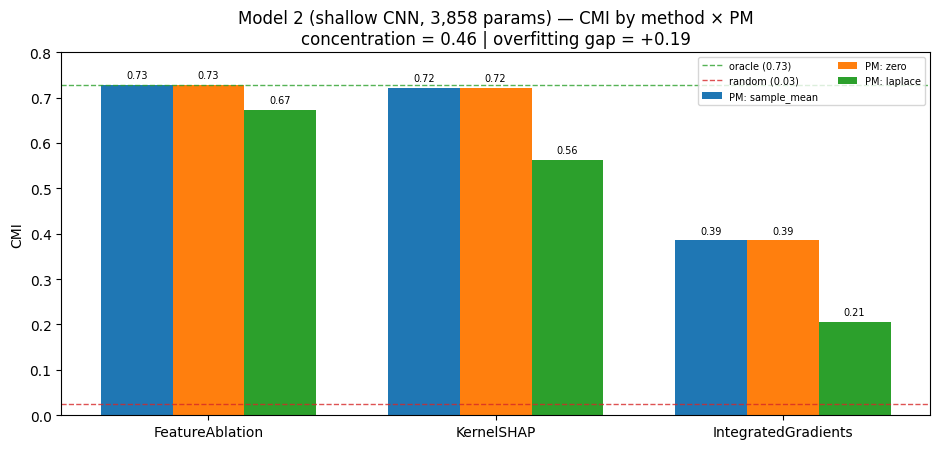

In [10]:
# CMI comparison figure
fig, ax = plt.subplots(figsize=(9.5, 4.6))
methods = list(cmi); x = np.arange(len(methods)); w = 0.25
for i, pm in enumerate(PMS):
    vals = [cmi[m][pm]["CMI"] for m in methods]
    bars = ax.bar(x + (i-1)*w, vals, w, label=f"PM: {pm}")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
ax.axhline(oracle_cmi, color="C2", ls="--", lw=1, alpha=0.8, label=f"oracle ({oracle_cmi:.2f})")
ax.axhline(random_cmi, color="C3", ls="--", lw=1, alpha=0.8, label=f"random ({random_cmi:.2f})")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("CMI"); ax.set_ylim(0, 0.8)
ax.set_title(f"Model 2 (shallow CNN, {n_params:,} params) — CMI by method × PM\n"
             f"concentration = {conc['mean']:.2f} | overfitting gap = {overfit_gap:+.2f}")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "04_model2_cmi.png", dpi=150, bbox_inches="tight"); plt.show()

### Region-0 edge-effect check

All three methods ranked **region 0 (the signal boundary)** most important — a possible edge
artifact we're tracking. Under MoRF, region 0 tends to be hidden **first**. We inspect the mean
deletion curves and the model's own per-region reliance to judge whether region 0 is **genuine
reliance** or a **boundary artifact**.

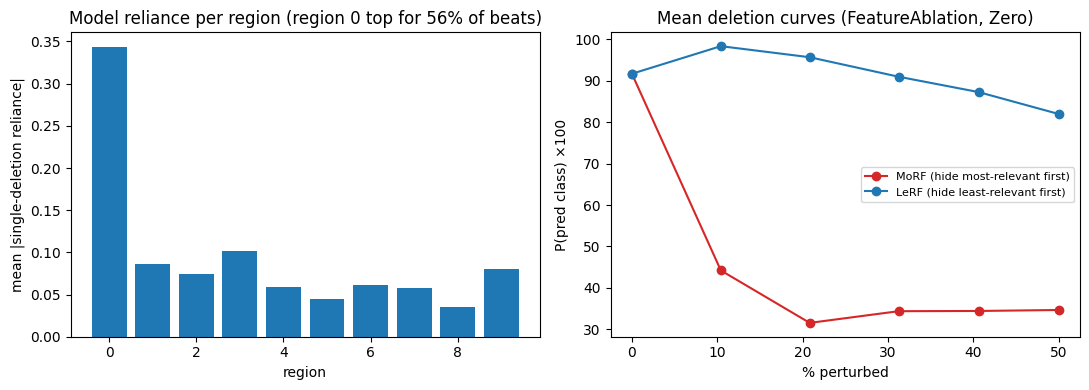

MoRF: [91.7 44.2 31.6 34.4 34.4 34.7]  |  step-1 drop = 47.5 of 57.0 total (83%)
FeatureAblation CMI under Laplace (non-zeroing PM) = 0.673


In [11]:
rel = np.array([region_reliance(predict_proba, s, grid, "zero") for s in X_test])
top0_frac = (np.argmax(np.abs(rel), axis=1) == 0).mean()

# mean MoRF/LeRF (FeatureAblation, zero) to see where the drop happens
M, L = [], []
for s in X_test:
    cur = perturbation_curves(predict_proba, s, grid, feature_ablation(predict_proba, s, grid, "zero"), method="zero")
    M.append(cur["MoRF"]); L.append(cur["LeRF"]); frac = cur["fraction_perturbed"]
M, L = np.array(M).mean(0), np.array(L).mean(0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(np.arange(grid.n_regions), np.abs(rel).mean(0), color="C0")
ax[0].set_xlabel("region"); ax[0].set_ylabel("mean |single-deletion reliance|")
ax[0].set_title(f"Model reliance per region (region 0 top for {top0_frac:.0%} of beats)")
ax[1].plot(frac*100, M, "-o", color="C3", label="MoRF (hide most-relevant first)")
ax[1].plot(frac*100, L, "-o", color="C0", label="LeRF (hide least-relevant first)")
ax[1].set_xlabel("% perturbed"); ax[1].set_ylabel("P(pred class) ×100"); ax[1].legend(fontsize=8)
ax[1].set_title("Mean deletion curves (FeatureAblation, Zero)")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_model2_region0.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"MoRF: {np.round(M,1)}  |  step-1 drop = {M[0]-M[1]:.1f} of {M[0]-M[-1]:.1f} total ({(M[0]-M[1])/(M[0]-M[-1]):.0%})")
print(f"FeatureAblation CMI under Laplace (non-zeroing PM) = {cmi['FeatureAblation']['laplace']['CMI']:.3f}")

### Model 2's row, the Model-1 comparison, and the read

**Model 2 full row (params 3,858 · concentration 0.47 · overfitting gap +0.19):**

| Method | SampleMean | Zero | Laplace |
|---|---|---|---|
| FeatureAblation | 0.728 | 0.728 | 0.673 |
| KernelSHAP | 0.721 | 0.721 | 0.563 |
| IntegratedGradients | 0.386 | 0.386 | 0.206 |

Controls: **random 0.025, oracle 0.728**.

**Sanity vs controls — passes.** Every real method scores **well above random (0.025)** — even the
weakest (IG–Laplace 0.206) is ~8× the random floor. FeatureAblation and KernelSHAP sit **right at the
oracle level (~0.72)**; FeatureAblation(Zero) equals the oracle exactly because with a zero baseline
it computes the oracle's reliance. No method is near-zero. **SampleMean ≡ Zero** for every method
(per-sample z-scoring makes the mean baseline ≈ zero), as on Model 1.

**IG is clearly less faithful than the perturbation methods (~0.39 vs ~0.72).** This is a real result,
not a bug — IG passed its sanity checks (completeness held, non-degenerate) and agreed with FA/KS on
the *average* importance profile. But its **PES is only 0.56** (vs 1.00 for FA/KS): IG's per-beat
ranking points the faithful way on only ~78% of beats. IG spreads importance into regions 1–3 where
FA/KS concentrate on region 0, so it ranks the model's true reliance less sharply → lower CMI. A
useful early signal that the gradient method and the deletion methods can genuinely disagree in
faithfulness even when they look similar on average.

**Region-0 edge check — looks mostly genuine, with a residual caveat.** Region 0 carries most of the
model's single-deletion reliance and is the top region for **56%** of beats, and the mean MoRF curve
does most of its work in the **first step** (~83% of the total drop). That sharp early drop is what a
faithful attribution *should* produce, but the boundary location invites an edge-artifact worry. The
key evidence it's largely genuine: under the **Laplace PM — which replaces the region with curvature,
not zeros — FeatureAblation still scores 0.673**. If region 0's importance were purely a zero-baseline
boundary discontinuity, a non-zeroing perturbation would collapse it; it doesn't. Combined with the
multi-method + model-reliance agreement and 01b's early-divergence finding, region 0 reads as **mostly
genuine reliance**, though a small edge component at the very boundary can't be fully excluded —
tracked as a caveat across all models.

**Model 1 vs Model 2 — first glimpse, do NOT over-read (two points, one caveated):**

| | Params | KS (Zero) | FA (Zero) | IG (Zero) | Concentration | Overfit gap |
|---|---|---|---|---|---|---|
| Model 1 (linear) | ~6 | 0.612 | 0.648 | — (no gradients) | 0.24 | ~0.20 |
| **Model 2 (shallow CNN)** | 3,858 | **0.721** | **0.728** | **0.386** | **0.47** | +0.19 |

CMI rises from Model 1 to Model 2 for the two comparable methods (KS, FA) — **but this is confounded**
and must not be read as "attributions got more faithful". Two reasons: (1) **Model 1 is an imperfect
anchor** — it reasons in *frequency-band* space (diffuse, concentration 0.24), not the time-region
space the harness perturbs, so it isn't a like-for-like point; and it has **no IG** (needs gradients),
so only KS/FA are comparable. (2) **Concentration also rose (0.24 → 0.47)** — a more concentrated
model has a higher CMI *ceiling* regardless of attribution quality, so part of the CMI increase is the
concentration confound, not faithfulness. Model 2 is the **first clean, time-domain-native data
point**; the meaningful trend will be **Model 2 vs Models 3–5**, read alongside concentration and the
overfitting gap. One point of the clean series is down; we don't interpret a trend from it yet.